In [ ]:
# Check GPU
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
Device: Tesla T4


Training on: cuda


100%|██████████| 170M/170M [01:59<00:00, 1.43MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]



Starting baseline training...

Epoch [1/10] Loss: 0.9844 | Accuracy: 72.68%
Epoch [2/10] Loss: 0.6262 | Accuracy: 79.19%
Epoch [3/10] Loss: 0.4779 | Accuracy: 80.03%
Epoch [4/10] Loss: 0.3818 | Accuracy: 80.82%
Epoch [5/10] Loss: 0.3003 | Accuracy: 80.47%
Epoch [6/10] Loss: 0.2523 | Accuracy: 81.72%
Epoch [7/10] Loss: 0.2014 | Accuracy: 82.17%
Epoch [8/10] Loss: 0.1650 | Accuracy: 81.59%
Epoch [9/10] Loss: 0.1309 | Accuracy: 81.75%
Epoch [10/10] Loss: 0.1228 | Accuracy: 80.78%

Training complete in 4.51 minutes

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.78      0.85      0.82      1000
  automobile       0.92      0.89      0.90      1000
        bird       0.70      0.81      0.75      1000
         cat       0.65      0.66      0.66      1000
        deer       0.78      0.82      0.80      1000
         dog       0.80      0.61      0.69      1000
        frog       0.90      0.82      0.86      1000
       horse      

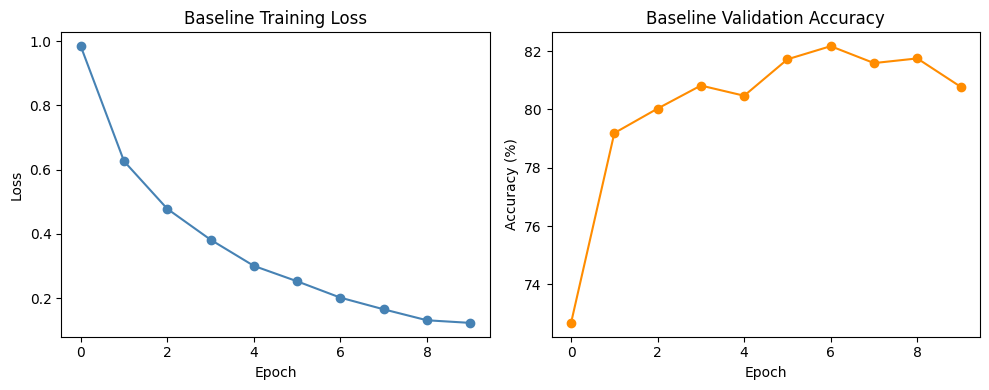


Done!
Model saved!


In [ ]:
# Baseline ResNet-18 on CIFAR-10
# No modifications — pure out-of-the-box

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import seaborn as sns
import numpy as np
import time

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Data Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Training
EPOCHS = 10
train_losses = []
val_accuracies = []

print("\nStarting baseline training...\n")
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)

    # Validation accuracy
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    val_accuracies.append(acc)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes")

# Final Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=classes))

# Plot Results
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', color='steelblue')
plt.title("Baseline Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, marker='o', color='darkorange')
plt.title("Baseline Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.savefig("baseline_results.png")
plt.show()
print("\nDone!")

# Save Model
torch.save(model.state_dict(), "baseline_model.pth")
print("Model saved!")

Training on: cuda

Starting improved training...

Epoch [1/20] Loss: 1.1605 | Accuracy: 72.35% | LR: 0.009938
Epoch [2/20] Loss: 0.8274 | Accuracy: 76.87% | LR: 0.009755
Epoch [3/20] Loss: 0.7189 | Accuracy: 76.53% | LR: 0.009455
Epoch [4/20] Loss: 0.6778 | Accuracy: 79.00% | LR: 0.009045
Epoch [5/20] Loss: 0.5916 | Accuracy: 81.55% | LR: 0.008536
Epoch [6/20] Loss: 0.5509 | Accuracy: 81.95% | LR: 0.007939
Epoch [7/20] Loss: 0.5153 | Accuracy: 82.33% | LR: 0.007270
Epoch [8/20] Loss: 0.4764 | Accuracy: 83.09% | LR: 0.006545
Epoch [9/20] Loss: 0.4406 | Accuracy: 84.00% | LR: 0.005782
Epoch [10/20] Loss: 0.4188 | Accuracy: 83.72% | LR: 0.005000
Epoch [11/20] Loss: 0.3842 | Accuracy: 84.68% | LR: 0.004218
Epoch [12/20] Loss: 0.3611 | Accuracy: 85.52% | LR: 0.003455
Epoch [13/20] Loss: 0.3397 | Accuracy: 85.34% | LR: 0.002730
Epoch [14/20] Loss: 0.3113 | Accuracy: 85.64% | LR: 0.002061
Epoch [15/20] Loss: 0.2898 | Accuracy: 86.39% | LR: 0.001464
Epoch [16/20] Loss: 0.2747 | Accuracy: 86.70

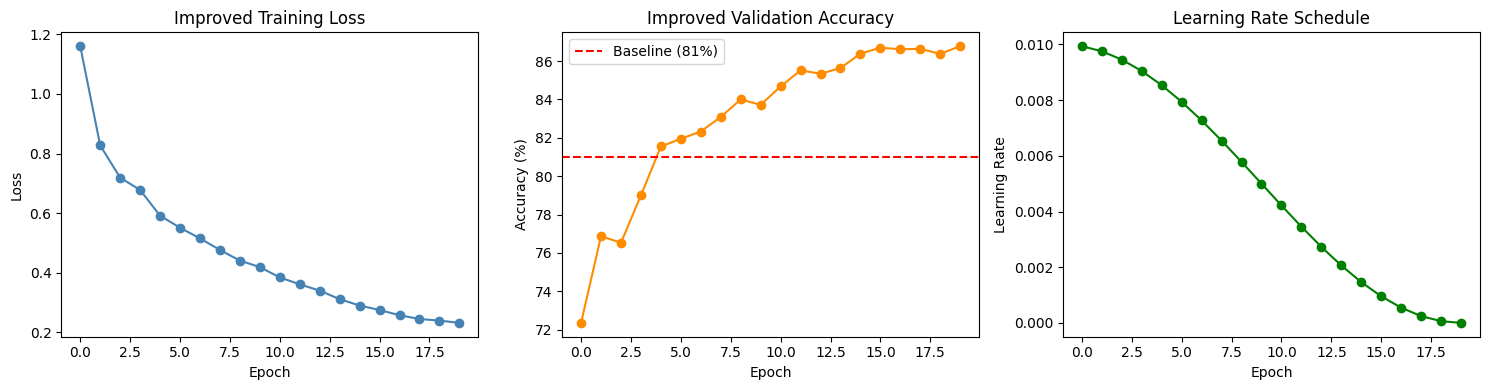


Done!
Improved model saved!


In [ ]:
# Improved ResNet-18 on CIFAR-10
# Enhancements: Data Augmentation + LR Scheduling

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
import time

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Improved Data Loading with Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # Randomly flip images
    transforms.RandomCrop(32, padding=4),        # Random crop with padding
    transforms.ColorJitter(                      # Random color changes
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(                        # Better normalization
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

# Test set gets NO augmentation — only normalization
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Model
model = models.resnet18(weights='ResNet18_Weights.IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4       # L2 regularization
)

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20                # Smoothly decays LR over 20 epochs
)

# Training
EPOCHS = 20                 # More epochs for better convergence
train_losses = []
val_accuracies = []
lr_history = []

print("\nStarting improved training...\n")
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)

    # Validation accuracy
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    val_accuracies.append(acc)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}% | LR: {current_lr:.6f}")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes")

# Final Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- Improved Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=classes))

# Plot Results
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses, marker='o', color='steelblue')
plt.title("Improved Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 3, 2)
plt.plot(val_accuracies, marker='o', color='darkorange')
plt.axhline(y=81.00, color='red', linestyle='--', label='Baseline (81%)')
plt.title("Improved Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(lr_history, marker='o', color='green')
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.tight_layout()
plt.savefig("improved_results.png")
plt.show()
print("\nDone!")

# Save Model
torch.save(model.state_dict(), "improved_model.pth")
print("Improved model saved!")

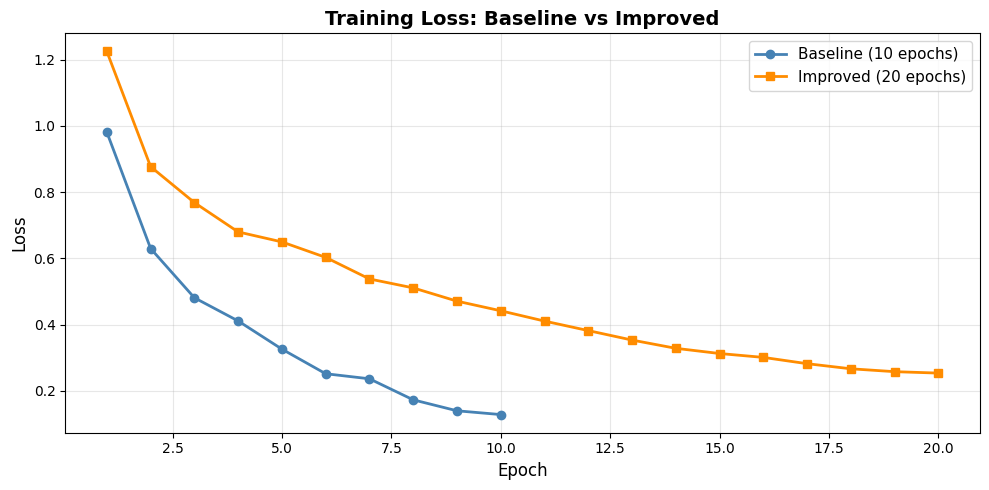

Chart 1 saved.


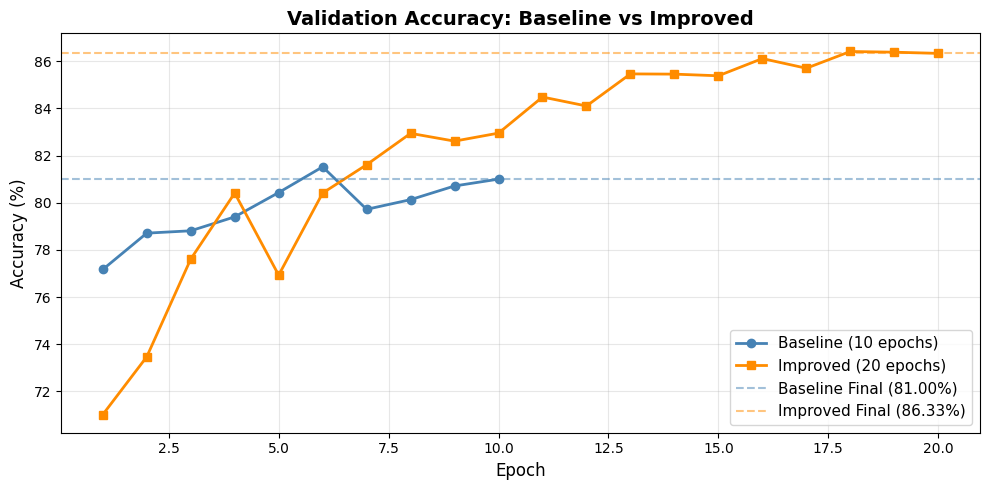

Chart 2 saved.


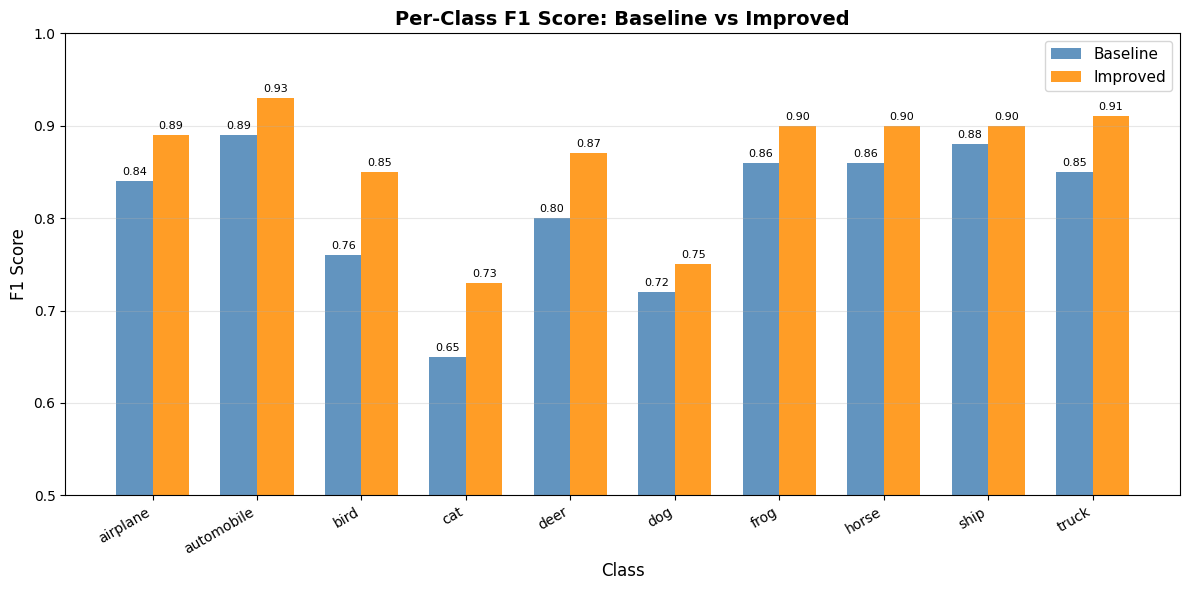

Chart 3 saved.


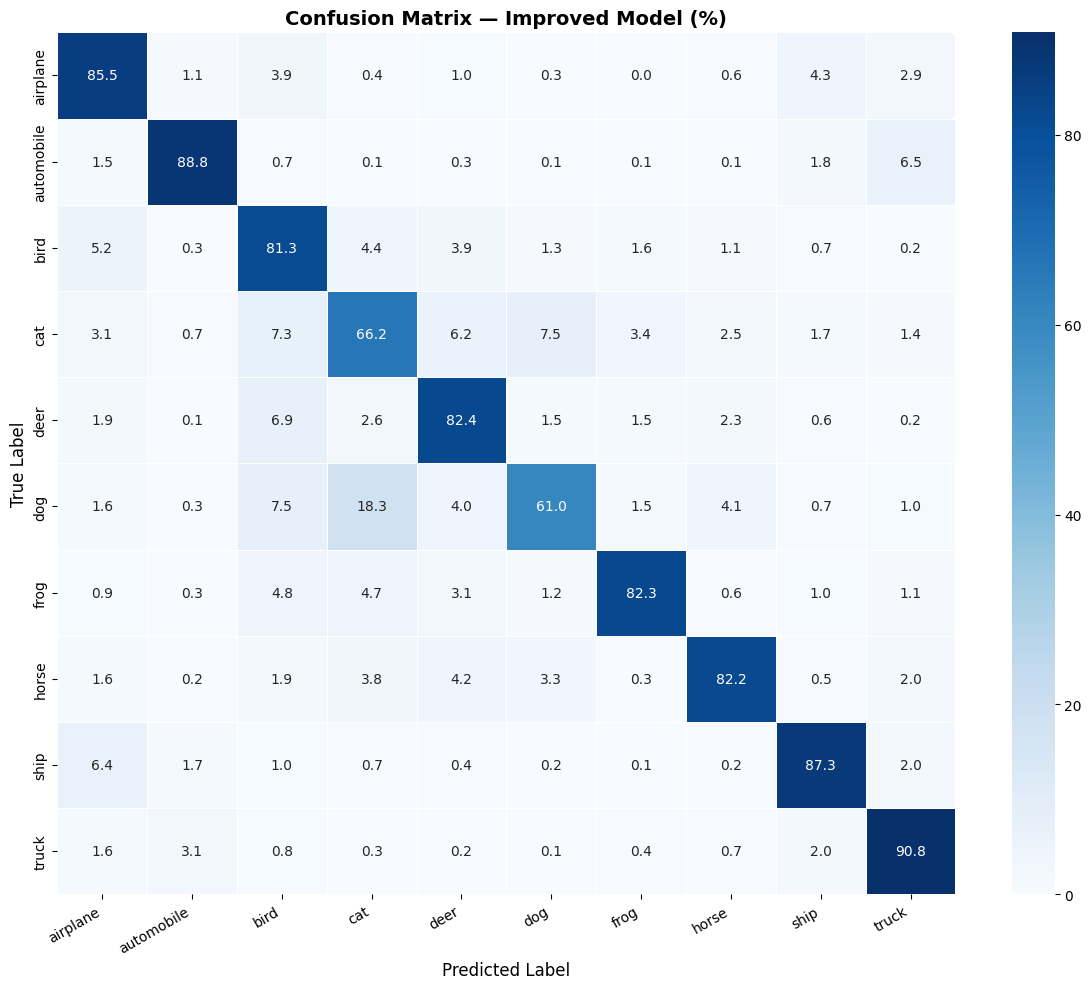

Chart 4 saved.


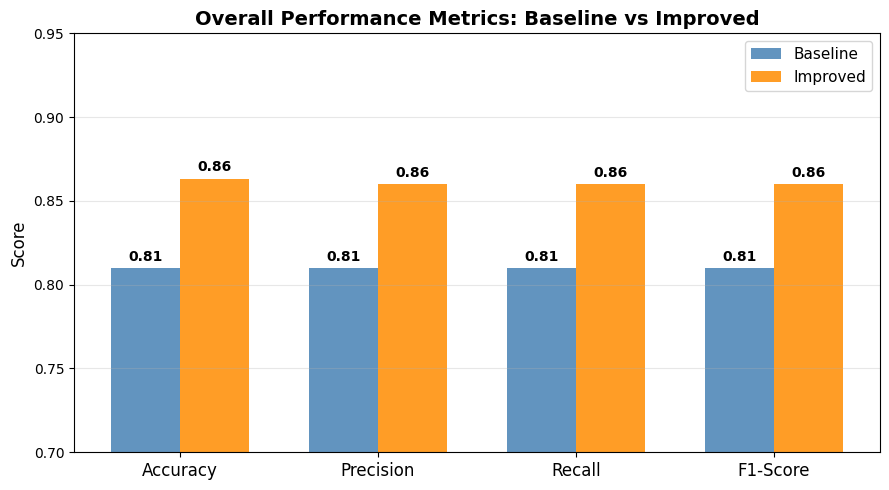

Chart 5 saved.

 All 5 charts generated and saved successfully!


In [ ]:
# Evaluation Charts — Baseline vs Improved

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Your recorded results
epochs_baseline = list(range(1, 11))
epochs_improved = list(range(1, 21))

baseline_losses = [
    0.9810, 0.6299, 0.4812, 0.4112, 0.3261,
    0.2519, 0.2366, 0.1731, 0.1400, 0.1286
]

baseline_accuracies = [
    77.17, 78.71, 78.81, 79.40, 80.43,
    81.52, 79.72, 80.13, 80.71, 81.00
]

improved_losses = [
    1.2247, 0.8770, 0.7685, 0.6800, 0.6498,
    0.6031, 0.5380, 0.5110, 0.4710, 0.4419,
    0.4108, 0.3821, 0.3535, 0.3286, 0.3129,
    0.3012, 0.2822, 0.2668, 0.2581, 0.2538
]

improved_accuracies = [
    71.02, 73.47, 77.61, 80.41, 76.93,
    80.41, 81.61, 82.94, 82.61, 82.95,
    84.48, 84.10, 85.46, 85.45, 85.38,
    86.11, 85.70, 86.41, 86.38, 86.33
]

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Baseline per-class F1
baseline_f1 = [0.84, 0.89, 0.76, 0.65, 0.80,
               0.72, 0.86, 0.86, 0.88, 0.85]

# Improved per-class F1
improved_f1 = [0.89, 0.93, 0.85, 0.73, 0.87,
               0.75, 0.90, 0.90, 0.90, 0.91]

# Chart 1 — Training Loss Comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs_baseline, baseline_losses, marker='o',
         color='steelblue', linewidth=2, label='Baseline (10 epochs)')
plt.plot(epochs_improved, improved_losses, marker='s',
         color='darkorange', linewidth=2, label='Improved (20 epochs)')
plt.title("Training Loss: Baseline vs Improved", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("chart1_loss_comparison.png", dpi=150)
plt.show()
print("Chart 1 saved.")

# Chart 2 — Validation Accuracy Comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs_baseline, baseline_accuracies, marker='o',
         color='steelblue', linewidth=2, label='Baseline (10 epochs)')
plt.plot(epochs_improved, improved_accuracies, marker='s',
         color='darkorange', linewidth=2, label='Improved (20 epochs)')
plt.axhline(y=81.00, color='steelblue', linestyle='--', alpha=0.5, label='Baseline Final (81.00%)')
plt.axhline(y=86.33, color='darkorange', linestyle='--', alpha=0.5, label='Improved Final (86.33%)')
plt.title("Validation Accuracy: Baseline vs Improved", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("chart2_accuracy_comparison.png", dpi=150)
plt.show()
print("Chart 2 saved.")

# Chart 3 — Per-Class F1 Score Comparison
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_f1, width,
               label='Baseline', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, improved_f1, width,
               label='Improved', color='darkorange', alpha=0.85)

ax.set_title("Per-Class F1 Score: Baseline vs Improved", fontsize=14, fontweight='bold')
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("chart3_perclass_f1.png", dpi=150)
plt.show()
print("Chart 3 saved.")

# Chart 4 — Confusion Matrix (Improved Model)
# Re-run predictions for confusion matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(12, 10))
sns.heatmap(cm_percent, annot=True, fmt='.1f',
            xticklabels=classes, yticklabels=classes,
            cmap='Blues', linewidths=0.5)
plt.title("Confusion Matrix — Improved Model (%)", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("chart4_confusion_matrix.png", dpi=150)
plt.show()
print("Chart 4 saved.")

# Chart 5 — Overall Metrics Summary
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [0.81, 0.81, 0.81, 0.81]
improved_scores = [0.8633, 0.86, 0.86, 0.86]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_scores, width,
               label='Baseline', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, improved_scores, width,
               label='Improved', color='darkorange', alpha=0.85)

ax.set_title("Overall Performance Metrics: Baseline vs Improved",
             fontsize=14, fontweight='bold')
ax.set_ylabel("Score", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.70, 0.95)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("chart5_overall_metrics.png", dpi=150)
plt.show()
print("Chart 5 saved.")

print("\n All 5 charts generated and saved successfully!")